# Experimento 7 — Estatísticas detalhadas

As cinco features do Exp. 4 + nove diferenças de estatísticas detalhadas, sem Elo.
Mantemos `SeedDif` (nome utilizado no projeto) e todas as diferenças A − B.

FG%, 3P% e FT% = soma dos acertos / soma das tentativas, em escala 0–1.
Assistências, rebotes ofensivos/defensivos, turnovers, roubos e bloqueios = média por jogo.

**Exp. 7 possui mais features, porém utiliza apenas temporadas com estatísticas detalhadas disponíveis:**
masculino desde 2003 e feminino desde 2010. Também comparamos Exp. 4 e Exp. 7 com
ambas as categorias restritas a 2010+, nos mesmos jogos históricos e de validação.


## Configuração

Validação expansiva 2021–2025, modelos M/W separados e seleção pela média simples
dos cinco Logistic Briers combinados. Mesmos espaços Optuna e seed do Exp. 4:
2 opções na linear e 30 trials por modelo de árvores, **em cada cenário**.


In [1]:
from pathlib import Path
import sys
import json
from importlib.metadata import version

import numpy as np
import pandas as pd
import optuna
from IPython.display import display

pasta_atual = Path.cwd().resolve()
raiz = next(
    (p for p in [pasta_atual, *pasta_atual.parents] if (p / "raw_data").is_dir()),
    None,
)
if raiz is None:
    raise FileNotFoundError("Pasta raw_data não encontrada.")
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

from src.data_processing import carregar_dados, preparar_seeds, organizar_jogos
from src.features import adicionar_seeds
from src.models import criar_regressao_linear, criar_random_forest, criar_xgboost
from src.tuning import otimizar_modelo
from src.submission import preparar_confrontos, prever_confrontos, salvar_submission

EXPERIMENTO = "exp7_features_detalhadas"
FEATURES_EXP4 = ["SeedDif", "WinRateDiff", "AvgPointsForDiff", "AvgPointsAgainstDiff", "OppWinRateDiff"]
ANOS_VALIDACAO = list(range(2021, 2026))
TEMPORADA_PREVISAO = 2026
SEED = 42
N_JOBS_MODELO = 2
CATEGORIAS = {"M": "Masculino", "W": "Feminino"}
CRIADORES = {
    "linear": criar_regressao_linear,
    "random_forest": criar_random_forest,
    "xgboost": criar_xgboost,
}
NOMES = {"linear": "Regressão linear", "random_forest": "Random Forest", "xgboost": "XGBoost"}
N_TRIALS = {"linear": 2, "random_forest": 30, "xgboost": 30}
PARAMETROS_FIXOS = {
    "linear": {},
    "random_forest": {"random_state": SEED, "n_jobs": N_JOBS_MODELO},
    "xgboost": {
        "random_state": SEED, "n_jobs": N_JOBS_MODELO,
        "objective": "reg:squarederror", "tree_method": "hist",
    },
}
ESPACOS = {
    "linear": {
        "fit_intercept": {"tipo": "categorical", "choices": [False, True]},
    },
    "random_forest": {
        "n_estimators": {"tipo": "int", "low": 150, "high": 500, "step": 50},
        "max_depth": {"tipo": "categorical", "choices": [2, 3, 4, 6, 8, 12, None]},
        "min_samples_leaf": {"tipo": "int", "low": 2, "high": 80, "log": True},
        "max_features": {"tipo": "categorical", "choices": [0.5, 1.0]},
        "max_samples": {"tipo": "float", "low": 0.6, "high": 1.0},
    },
    "xgboost": {
        "n_estimators": {"tipo": "int", "low": 100, "high": 600, "step": 50},
        "max_depth": {"tipo": "int", "low": 1, "high": 5},
        "learning_rate": {"tipo": "float", "low": 0.01, "high": 0.15, "log": True},
        "min_child_weight": {"tipo": "float", "low": 5.0, "high": 80.0, "log": True},
        "subsample": {"tipo": "float", "low": 0.6, "high": 1.0},
        "colsample_bytree": {"tipo": "categorical", "choices": [0.5, 1.0]},
        "reg_alpha": {"tipo": "float", "low": 0.00001, "high": 10.0, "log": True},
        "reg_lambda": {"tipo": "float", "low": 0.1, "high": 100.0, "log": True},
        "gamma": {"tipo": "float", "low": 0.0, "high": 5.0},
    },
}
optuna.logging.set_verbosity(optuna.logging.WARNING)

from src.features import calcular_estatisticas_agregadas, adicionar_estatisticas
from src.tuning import avaliar_temporadas
LIMITE_DAYNUM_PREVISAO = 134


from src.features import (
    ESTATISTICAS_DETALHADAS, calcular_estatisticas_detalhadas, adicionar_estatisticas_detalhadas,
)
FEATURES = [*FEATURES_EXP4, *[nome + "Diff" for nome in ESTATISTICAS_DETALHADAS]]
INICIO_DETALHADO = {"M": 2003, "W": 2010}
INICIO_COMUM = 2010
CENARIO_PRINCIPAL = "Exp7 disponivel"

REFERENCIA_EXP4 = json.loads(r'''{"melhores_parametros": {"linear": {"fit_intercept": true}, "random_forest": {"random_state": 42, "n_jobs": 2, "n_estimators": 500, "max_depth": 4, "min_samples_leaf": 6, "max_features": 0.5, "max_samples": 0.6065760550178787}, "xgboost": {"random_state": 42, "n_jobs": 2, "objective": "reg:squarederror", "tree_method": "hist", "n_estimators": 150, "max_depth": 3, "learning_rate": 0.012689764289026415, "min_child_weight": 8.607635238510117, "subsample": 0.6580133184316654, "colsample_bytree": 0.5, "reg_alpha": 0.0024896301334778855, "reg_lambda": 2.8889382262130026, "gamma": 0.6608413857851283}}, "melhores_medias": {"linear": 0.07102647699289884, "random_forest": 0.06868149782959243, "xgboost": 0.06756812913405244}, "versoes": {"numpy": "2.2.6", "pandas": "2.3.2", "scikit-learn": "1.7.1", "xgboost": "3.0.5", "optuna": "4.9.0"}, "fonte": "notebooks/features_incrementais/exp4_features_agregadas.ipynb: registro do experimento"}''')


## Preparação e cobertura

Usamos apenas RegularSeasonCompactResults e RegularSeasonDetailedResults, com os
mesmos cortes pré-NCAA. Em 2026: DayNum < 134. Não preenchemos temporadas antigas
nem descartamos silenciosamente jogos do torneio sem features.

No feminino faltam detalhes de 103 jogos em 2010, 54 em 2011 e 64 em 2012.
As nove features novas usam os jogos detalhados disponíveis; as cinco do Exp. 4
continuam usando todos os jogos regulares. A cobertura é auditada abaixo.


In [2]:
dados = {
    categoria: carregar_dados(raiz / "raw_data", categoria, incluir_regular=True, incluir_detalhado=True)
    for categoria in CATEGORIAS
}
assert set(dados["M"]["times"]["TeamID"]).isdisjoint(set(dados["W"]["times"]["TeamID"]))
seeds, estatisticas, detalhadas, jogos, limites, coberturas = {}, {}, {}, {}, {}, []
chaves_jogo = ["Season", "DayNum", "WTeamID", "LTeamID"]
for categoria, base in dados.items():
    torneios = base["resultados"].loc[base["resultados"]["Season"] < TEMPORADA_PREVISAO].copy()
    limites[categoria] = torneios.groupby("Season")["DayNum"].min().to_dict()
    limites[categoria][TEMPORADA_PREVISAO] = LIMITE_DAYNUM_PREVISAO
    raw_detalhes = base["temporada_regular_detalhada"]
    assert raw_detalhes["Season"].min() == INICIO_DETALHADO[categoria]
    anos = set(raw_detalhes["Season"]) & set(limites[categoria])
    assert set([*ANOS_VALIDACAO, TEMPORADA_PREVISAO]).issubset(anos)
    regulares = base["temporada_regular"].loc[base["temporada_regular"]["Season"].isin(anos)].copy()
    detalhes = raw_detalhes.loc[raw_detalhes["Season"].isin(anos)].copy()
    ids = set(base["times"]["TeamID"])
    for tabela in [regulares, detalhes]:
        assert (tabela["DayNum"] < tabela["Season"].map(limites[categoria])).all()
        assert tabela.merge(torneios[chaves_jogo], on=chaves_jogo).empty
        assert tabela["WTeamID"].isin(ids).all() and tabela["LTeamID"].isin(ids).all()
    conferidos = detalhes.merge(regulares[chaves_jogo + ["WScore", "LScore"]],
        on=chaves_jogo, how="left", suffixes=("", "Compact"), validate="one_to_one", indicator=True)
    assert conferidos["_merge"].eq("both").all()
    for placar in ["WScore", "LScore"]:
        np.testing.assert_array_equal(conferidos[placar], conferidos[placar + "Compact"])

    cobertura = regulares.groupby("Season").size().rename("JogosCompact").to_frame()
    cobertura["JogosDetalhados"] = detalhes.groupby("Season").size()
    cobertura["SemDetalhes"] = cobertura["JogosCompact"] - cobertura["JogosDetalhados"]
    cobertura["Cobertura"] = cobertura["JogosDetalhados"] / cobertura["JogosCompact"]
    cobertura["UltimoDayNumDetalhado"] = detalhes.groupby("Season")["DayNum"].max()
    cobertura["LimiteExclusivo"] = cobertura.index.map(limites[categoria])
    coberturas.append(cobertura.reset_index().assign(Categoria=categoria))
    seeds[categoria] = preparar_seeds(base["seeds"])
    estatisticas[categoria] = calcular_estatisticas_agregadas(regulares, limites_daynum=limites[categoria])
    detalhadas[categoria] = calcular_estatisticas_detalhadas(detalhes, limites_daynum=limites[categoria])
    historico = torneios.loc[torneios["Season"].isin(anos)]
    tabela = adicionar_seeds(organizar_jogos(historico), seeds[categoria])
    tabela = adicionar_estatisticas(tabela, estatisticas[categoria])
    tabela = adicionar_estatisticas_detalhadas(tabela, detalhadas[categoria])
    assert len(tabela) == len(historico)
    assert (tabela["TeamA"] < tabela["TeamB"]).all()
    assert tabela["Target"].equals(tabela["ScoreA"] - tabela["ScoreB"])
    assert tabela["SeedDif"].equals(tabela["SeedA"] - tabela["SeedB"])
    assert np.isfinite(tabela[FEATURES].to_numpy()).all()
    for stats, nomes in [(estatisticas[categoria], ["WinRate", "AvgPointsFor", "AvgPointsAgainst", "OppWinRate"]),
                          (detalhadas[categoria], ESTATISTICAS_DETALHADAS)]:
        lookup = stats.set_index(["Season", "TeamID"])
        for nome in nomes:
            a = lookup[nome].reindex(pd.MultiIndex.from_frame(tabela[["Season", "TeamA"]])).to_numpy()
            b = lookup[nome].reindex(pd.MultiIndex.from_frame(tabela[["Season", "TeamB"]])).to_numpy()
            np.testing.assert_allclose(tabela[nome + "Diff"], a - b)
    jogos[categoria] = tabela

cobertura = pd.concat(coberturas, ignore_index=True)
display(cobertura)
jogos_2010 = {categoria: tabela.loc[tabela["Season"] >= INICIO_COMUM].copy() for categoria, tabela in jogos.items()}
CENARIOS = {
    "Exp7 disponivel": {"dados": jogos, "features": FEATURES},
    "Exp4 2010+": {"dados": jogos_2010, "features": FEATURES_EXP4},
    "Exp7 2010+": {"dados": jogos_2010, "features": FEATURES},
}
divisoes = pd.DataFrame([
    {"Cenario": cenario, "Categoria": categoria, "AnoValidacao": ano,
     "PrimeiroAnoTreino": tabela.loc[tabela["Season"] < ano, "Season"].min(),
     "UltimoAnoTreino": tabela.loc[tabela["Season"] < ano, "Season"].max(),
     "JogosTreino": int(tabela["Season"].lt(ano).sum()),
     "JogosValidacao": int(tabela["Season"].eq(ano).sum())}
    for cenario, config in CENARIOS.items() for categoria, tabela in config["dados"].items()
    for ano in ANOS_VALIDACAO
])
assert (divisoes["UltimoAnoTreino"] < divisoes["AnoValidacao"]).all()
assert divisoes["JogosValidacao"].gt(0).all()
assert divisoes.loc[divisoes["AnoValidacao"].eq(2021), "UltimoAnoTreino"].eq(2019).all()
display(divisoes)


,Season,JogosCompact,JogosDetalhados,SemDetalhes,Cobertura,UltimoDayNumDetalhado,LimiteExclusivo,Categoria
0,2003,4616,4616,0,1.000000,132,134,M
1,2004,4571,4571,0,1.000000,132,134,M
2,2005,4675,4675,0,1.000000,132,134,M
3,2006,4757,4757,0,1.000000,132,134,M
4,2007,5043,5043,0,1.000000,132,134,M
5,2008,5163,5163,0,1.000000,132,134,M
6,2009,5249,5249,0,1.000000,132,134,M
7,2010,5263,5263,0,1.000000,132,134,M
8,2011,5246,5246,0,1.000000,132,134,M
9,2012,5253,5253,0,1.000000,132,134,M


,Cenario,Categoria,AnoValidacao,PrimeiroAnoTreino,UltimoAnoTreino,JogosTreino,JogosValidacao
0,Exp7 disponivel,M,2021,2003,2019,1115,66
1,Exp7 disponivel,M,2022,2003,2021,1181,67
2,Exp7 disponivel,M,2023,2003,2022,1248,67
3,Exp7 disponivel,M,2024,2003,2023,1315,67
4,Exp7 disponivel,M,2025,2003,2024,1382,67
5,Exp7 disponivel,W,2021,2010,2019,630,63
6,Exp7 disponivel,W,2022,2010,2021,693,67
7,Exp7 disponivel,W,2023,2010,2022,760,67
8,Exp7 disponivel,W,2024,2010,2023,827,67
9,Exp7 disponivel,W,2025,2010,2024,894,67


## Estatísticas e correlações

Features históricas por categoria, antes do treino.


In [3]:
correlacoes = {}
for categoria, nome in CATEGORIAS.items():
    tabela = jogos[categoria][FEATURES]
    verificacao = pd.DataFrame({
        "NaNs": tabela.isna().sum(),
        "Infinitos": np.isinf(tabela.to_numpy()).sum(axis=0),
    }, index=FEATURES)
    assert verificacao.to_numpy().sum() == 0
    print(nome)
    display(verificacao)
    display(tabela.describe().T.round(4))
    correlacoes[categoria] = tabela.corr()
    display(correlacoes[categoria].round(3))
    print(f"Correlação SeedDif × WinRateDiff: {correlacoes[categoria].loc['SeedDif', 'WinRateDiff']:.3f}")


Masculino


,NaNs,Infinitos
SeedDif,0,0
WinRateDiff,0,0
AvgPointsForDiff,0,0
AvgPointsAgainstDiff,0,0
OppWinRateDiff,0,0
FGPercentageDiff,0,0
ThreePointPercentageDiff,0,0
FTPercentageDiff,0,0
AssistsPerGameDiff,0,0
OffensiveReboundsPerGameDiff,0,0


,count,mean,std,min,25%,50%,75%,max
SeedDif,1449.0,-0.1077,7.4739,-15.0000,-5.0000,0.0000,5.0000,15.0000
WinRateDiff,1449.0,0.0015,0.1450,-0.6333,-0.0882,0.0009,0.0968,0.4917
AvgPointsForDiff,1449.0,0.8823,7.2409,-22.8929,-3.7951,1.0000,5.9519,21.6434
AvgPointsAgainstDiff,1449.0,0.5048,6.3787,-25.0357,-3.6970,0.4627,4.8425,20.0492
OppWinRateDiff,1449.0,-0.0013,0.0719,-0.2315,-0.0435,-0.0020,0.0419,0.2216
FGPercentageDiff,1449.0,0.0043,0.0321,-0.1362,-0.0170,0.0046,0.0251,0.1215
ThreePointPercentageDiff,1449.0,0.0035,0.0370,-0.1398,-0.0205,0.0033,0.0272,0.1283
FTPercentageDiff,1449.0,-0.0001,0.0505,-0.1728,-0.0346,0.0003,0.0350,0.1495
AssistsPerGameDiff,1449.0,0.1806,2.6244,-9.2326,-1.5943,0.2188,1.9915,8.3636
OffensiveReboundsPerGameDiff,1449.0,-0.0212,2.4837,-9.2143,-1.6765,0.0069,1.6657,7.9246


,SeedDif,WinRateDiff,AvgPointsForDiff,AvgPointsAgainstDiff,OppWinRateDiff,FGPercentageDiff,ThreePointPercentageDiff,FTPercentageDiff,AssistsPerGameDiff,OffensiveReboundsPerGameDiff,DefensiveReboundsPerGameDiff,TurnoversPerGameDiff,StealsPerGameDiff,BlocksPerGameDiff
SeedDif,1.000,-0.609,-0.427,0.217,-0.742,-0.340,-0.192,-0.077,-0.411,-0.279,-0.311,0.223,-0.096,-0.347
WinRateDiff,-0.609,1.000,0.439,-0.361,0.095,0.482,0.270,0.077,0.386,0.137,0.332,-0.254,0.144,0.230
AvgPointsForDiff,-0.427,0.439,1.000,0.549,0.232,0.569,0.374,0.179,0.625,0.337,0.491,0.066,0.251,0.224
AvgPointsAgainstDiff,0.217,-0.361,0.549,1.000,0.002,0.061,0.070,0.106,0.168,0.166,0.134,0.341,0.080,-0.063
OppWinRateDiff,-0.742,0.095,0.232,0.002,1.000,0.085,0.022,0.026,0.208,0.261,0.164,-0.107,0.023,0.291
FGPercentageDiff,-0.340,0.482,0.569,0.061,0.085,1.000,0.545,0.157,0.586,-0.222,0.343,-0.013,-0.073,0.072
ThreePointPercentageDiff,-0.192,0.270,0.374,0.070,0.022,0.545,1.000,0.279,0.339,-0.300,0.122,-0.176,-0.171,-0.099
FTPercentageDiff,-0.077,0.077,0.179,0.106,0.026,0.157,0.279,1.000,0.056,-0.338,-0.024,-0.234,-0.194,-0.200
AssistsPerGameDiff,-0.411,0.386,0.625,0.168,0.208,0.586,0.339,0.056,1.000,0.162,0.354,0.030,0.142,0.145
OffensiveReboundsPerGameDiff,-0.279,0.137,0.337,0.166,0.261,-0.222,-0.300,-0.338,0.162,1.000,0.215,0.289,0.309,0.389


Correlação SeedDif × WinRateDiff: -0.609
Feminino


,NaNs,Infinitos
SeedDif,0,0
WinRateDiff,0,0
AvgPointsForDiff,0,0
AvgPointsAgainstDiff,0,0
OppWinRateDiff,0,0
FGPercentageDiff,0,0
ThreePointPercentageDiff,0,0
FTPercentageDiff,0,0
AssistsPerGameDiff,0,0
OffensiveReboundsPerGameDiff,0,0


,count,mean,std,min,25%,50%,75%,max
SeedDif,961.0,0.4412,7.3305,-15.0000,-4.0000,1.0000,5.0000,15.0000
WinRateDiff,961.0,0.0095,0.1678,-0.4688,-0.1065,0.0119,0.1204,0.5484
AvgPointsForDiff,961.0,0.7461,9.4787,-30.8485,-5.4391,0.5000,6.8848,29.4242
AvgPointsAgainstDiff,961.0,-0.5466,7.1593,-29.9615,-5.3333,-0.3182,4.1792,27.8095
OppWinRateDiff,961.0,-0.0072,0.0854,-0.2734,-0.0625,-0.0080,0.0436,0.2850
FGPercentageDiff,961.0,0.0060,0.0471,-0.1411,-0.0261,0.0047,0.0367,0.1545
ThreePointPercentageDiff,961.0,0.0018,0.0441,-0.1183,-0.0284,0.0011,0.0298,0.1549
FTPercentageDiff,961.0,-0.0008,0.0574,-0.1815,-0.0407,-0.0007,0.0394,0.1830
AssistsPerGameDiff,961.0,0.6573,3.5232,-9.8433,-1.6099,0.5161,2.9485,11.5588
OffensiveReboundsPerGameDiff,961.0,-0.1170,2.9063,-9.0267,-2.1562,-0.1532,1.9024,9.2848


,SeedDif,WinRateDiff,AvgPointsForDiff,AvgPointsAgainstDiff,OppWinRateDiff,FGPercentageDiff,ThreePointPercentageDiff,FTPercentageDiff,AssistsPerGameDiff,OffensiveReboundsPerGameDiff,DefensiveReboundsPerGameDiff,TurnoversPerGameDiff,StealsPerGameDiff,BlocksPerGameDiff
SeedDif,1.000,-0.540,-0.607,0.126,-0.804,-0.586,-0.329,-0.126,-0.454,-0.265,-0.396,0.164,-0.059,-0.425
WinRateDiff,-0.540,1.000,0.618,-0.465,0.140,0.654,0.440,0.178,0.544,0.185,0.413,-0.380,0.136,0.363
AvgPointsForDiff,-0.607,0.618,1.000,0.185,0.372,0.767,0.522,0.350,0.727,0.242,0.469,-0.203,0.226,0.317
AvgPointsAgainstDiff,0.126,-0.465,0.185,1.000,0.068,-0.160,-0.026,0.172,-0.047,-0.044,-0.061,0.310,-0.064,-0.276
OppWinRateDiff,-0.804,0.140,0.372,0.068,1.000,0.366,0.165,0.088,0.269,0.179,0.269,-0.019,-0.031,0.330
FGPercentageDiff,-0.586,0.654,0.767,-0.160,0.366,1.000,0.640,0.329,0.762,-0.106,0.443,-0.243,0.031,0.314
ThreePointPercentageDiff,-0.329,0.440,0.522,-0.026,0.165,0.640,1.000,0.355,0.475,-0.250,0.274,-0.260,-0.110,0.123
FTPercentageDiff,-0.126,0.178,0.350,0.172,0.088,0.329,0.355,1.000,0.285,-0.349,0.142,-0.245,-0.161,-0.054
AssistsPerGameDiff,-0.454,0.544,0.727,-0.047,0.269,0.762,0.475,0.285,1.000,-0.005,0.424,-0.188,0.148,0.266
OffensiveReboundsPerGameDiff,-0.265,0.185,0.242,-0.044,0.179,-0.106,-0.250,-0.349,-0.005,1.000,0.078,0.248,0.333,0.259


Correlação SeedDif × WinRateDiff: -0.540


## Optuna

Otimizamos os três cenários separadamente, com o mesmo orçamento. A comparação
2010+ mantém as mesmas partidas e varia as features e os parâmetros selecionados.


In [4]:
buscas_cenarios = {}
for cenario, config in CENARIOS.items():
    buscas_cenarios[cenario] = {}
    for nome, criar_modelo in CRIADORES.items():
        sampler = (optuna.samplers.GridSampler({"fit_intercept": [False, True]}, seed=SEED)
                   if nome == "linear" else optuna.samplers.TPESampler(seed=SEED))
        buscas_cenarios[cenario][nome] = otimizar_modelo(
            config["dados"], criar_modelo, ESPACOS[nome], ANOS_VALIDACAO,
            features=config["features"], n_trials=N_TRIALS[nome],
            parametros_fixos=PARAMETROS_FIXOS[nome], sampler=sampler,
            seed=SEED, nome=f"exp7_{cenario}_{nome}",
        )
buscas = buscas_cenarios[CENARIO_PRINCIPAL]
resumo = pd.DataFrame([
    {"Cenario": cenario, "Modelo": NOMES[nome], "MediaLogisticBrier": r["media"],
     "MelhorTrial": r["estudo"].best_trial.number, "Tentativas": len(r["estudo"].trials),
     "Parametros": json.dumps(r["parametros"], ensure_ascii=False)}
    for cenario, resultados in buscas_cenarios.items() for nome, r in resultados.items()
])
display(resumo)
for cenario, resultados in buscas_cenarios.items():
    for nome, r in resultados.items():
        print(cenario, NOMES[nome], r["parametros"])


exp7_Exp7 disponivel_linear: 2/2; melhor média = 0.072359
exp7_Exp7 disponivel_random_forest: 5/30; melhor média = 0.070976
exp7_Exp7 disponivel_random_forest: 10/30; melhor média = 0.070947
exp7_Exp7 disponivel_random_forest: 15/30; melhor média = 0.070615
exp7_Exp7 disponivel_random_forest: 20/30; melhor média = 0.070615
exp7_Exp7 disponivel_random_forest: 25/30; melhor média = 0.070591
exp7_Exp7 disponivel_random_forest: 30/30; melhor média = 0.070591
exp7_Exp7 disponivel_xgboost: 5/30; melhor média = 0.069629
exp7_Exp7 disponivel_xgboost: 10/30; melhor média = 0.069629
exp7_Exp7 disponivel_xgboost: 15/30; melhor média = 0.069629
exp7_Exp7 disponivel_xgboost: 20/30; melhor média = 0.069629
exp7_Exp7 disponivel_xgboost: 25/30; melhor média = 0.069629
exp7_Exp7 disponivel_xgboost: 30/30; melhor média = 0.069629
exp7_Exp4 2010+_linear: 2/2; melhor média = 0.071555
exp7_Exp4 2010+_random_forest: 5/30; melhor média = 0.070673
exp7_Exp4 2010+_random_forest: 10/30; melhor média = 0.070651


,Cenario,Modelo,MediaLogisticBrier,MelhorTrial,Tentativas,Parametros
0,Exp7 disponivel,Regressão linear,0.072359,1,2,"{""fit_intercept"": false}"
1,Exp7 disponivel,Random Forest,0.070591,23,30,"{""random_state"": 42, ""n_jobs"": 2, ""n_estimator..."
2,Exp7 disponivel,XGBoost,0.069629,4,30,"{""random_state"": 42, ""n_jobs"": 2, ""objective"":..."
3,Exp4 2010+,Regressão linear,0.071555,0,2,"{""fit_intercept"": true}"
4,Exp4 2010+,Random Forest,0.070361,21,30,"{""random_state"": 42, ""n_jobs"": 2, ""n_estimator..."
5,Exp4 2010+,XGBoost,0.070342,23,30,"{""random_state"": 42, ""n_jobs"": 2, ""objective"":..."
6,Exp7 2010+,Regressão linear,0.072271,1,2,"{""fit_intercept"": false}"
7,Exp7 2010+,Random Forest,0.070830,16,30,"{""random_state"": 42, ""n_jobs"": 2, ""n_estimator..."
8,Exp7 2010+,XGBoost,0.070212,22,30,"{""random_state"": 42, ""n_jobs"": 2, ""objective"":..."


Exp7 disponivel Regressão linear {'fit_intercept': False}
Exp7 disponivel Random Forest {'random_state': 42, 'n_jobs': 2, 'n_estimators': 500, 'max_depth': 3, 'min_samples_leaf': 6, 'max_features': 0.5, 'max_samples': 0.6080031160783946}
Exp7 disponivel XGBoost {'random_state': 42, 'n_jobs': 2, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.01097599850212944, 'min_child_weight': 62.215825966390064, 'subsample': 0.7035119926400067, 'colsample_bytree': 0.5, 'reg_alpha': 0.013194961490425657, 'reg_lambda': 4.366473592979633, 'gamma': 0.9242722776276352}
Exp4 2010+ Regressão linear {'fit_intercept': True}
Exp4 2010+ Random Forest {'random_state': 42, 'n_jobs': 2, 'n_estimators': 500, 'max_depth': 4, 'min_samples_leaf': 7, 'max_features': 0.5, 'max_samples': 0.6038548971808506}
Exp4 2010+ XGBoost {'random_state': 42, 'n_jobs': 2, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'n_estimators': 150, 'max_depth': 3, 'lear

## Resultados e comparação

Exp. 4 original é a referência salva com todo o histórico. A comparação principal
para avaliar as novas features é **Exp4 2010+ × Exp7 2010+**. Menor é melhor.
Não usamos Kaggle na seleção; os anos de validação não são um teste independente.


In [5]:
comparacao = pd.concat([
    resumo[["Cenario", "Modelo", "MediaLogisticBrier"]],
    pd.DataFrame([{"Cenario": "Exp4 original", "Modelo": NOMES[nome], "MediaLogisticBrier": media}
                  for nome, media in REFERENCIA_EXP4["melhores_medias"].items()]),
], ignore_index=True)
tabela_comparacao = comparacao.pivot(index="Modelo", columns="Cenario", values="MediaLogisticBrier")
display(tabela_comparacao.round(6))
ganhos = tabela_comparacao[["Exp4 2010+", "Exp7 2010+"]].copy()
ganhos["GanhoExp7_2010"] = ganhos["Exp4 2010+"] - ganhos["Exp7 2010+"]
display(ganhos.round(6))
print("Ganho positivo indica redução do erro com as features detalhadas no recorte comum.")
scores_anuais = pd.concat([
    r["resultados"].assign(Modelo=NOMES[nome], Cenario=cenario)
    for cenario, resultados in buscas_cenarios.items() for nome, r in resultados.items()
], ignore_index=True)
display(scores_anuais.query("Categoria == 'Combinado'").pivot(
    index=["Modelo", "Season"], columns="Cenario", values="Score").round(6))
display(scores_anuais.loc[scores_anuais["Cenario"].eq(CENARIO_PRINCIPAL)].pivot(
    index=["Season", "Categoria"], columns="Modelo", values="Score").round(6))


Cenario,Exp4 2010+,Exp4 original,Exp7 2010+,Exp7 disponivel
Modelo,,,,
Random Forest,0.070361,0.068681,0.070830,0.070591
Regressão linear,0.071555,0.071026,0.072271,0.072359
XGBoost,0.070342,0.067568,0.070212,0.069629


Cenario,Exp4 2010+,Exp7 2010+,GanhoExp7_2010
Modelo,,,
Random Forest,0.070361,0.070830,-0.000469
Regressão linear,0.071555,0.072271,-0.000717
XGBoost,0.070342,0.070212,0.000130


Ganho positivo indica redução do erro com as features detalhadas no recorte comum.


Cenario                  Exp4 2010+  Exp7 2010+  Exp7 disponivel
Modelo           Season                                         
Random Forest    2021      0.082080    0.079056         0.078977
                 2022      0.080908    0.084144         0.083791
                 2023      0.077213    0.078865         0.078433
                 2024      0.056949    0.058413         0.058500
                 2025      0.054654    0.053671         0.053255
Regressão linear 2021      0.088978    0.085325         0.086745
                 2022      0.077799    0.082215         0.082456
                 2023      0.080370    0.081307         0.080960
                 2024      0.060736    0.061556         0.061428
                 2025      0.049889    0.050954         0.050206
XGBoost          2021      0.080192    0.079183         0.078818
                 2022      0.080922    0.082571         0.078209
                 2023      0.075404    0.074972         0.075280
                 2024      0.058689    0.059142         0.060964
                 2025      0.056504    0.055193         0.054874

Modelo            Random Forest  Regressão linear   XGBoost
Season Categoria                                           
2021   Combinado       0.078977          0.086745  0.078818
       M               0.090355          0.096232  0.089868
       W               0.067058          0.076806  0.067243
2022   Combinado       0.083791          0.082456  0.078209
       M               0.077885          0.093982  0.075412
       W               0.089696          0.070931  0.081006
2023   Combinado       0.078433          0.080960  0.075280
       M               0.084253          0.092645  0.081442
       W               0.072612          0.069274  0.069118
2024   Combinado       0.058500          0.061428  0.060964
       M               0.077042          0.077776  0.078188
       W               0.039957          0.045079  0.043741
2025   Combinado       0.053255          0.050206  0.054874
       M               0.056892          0.057622  0.058596
       W               0.049618          0.042790  0.051152

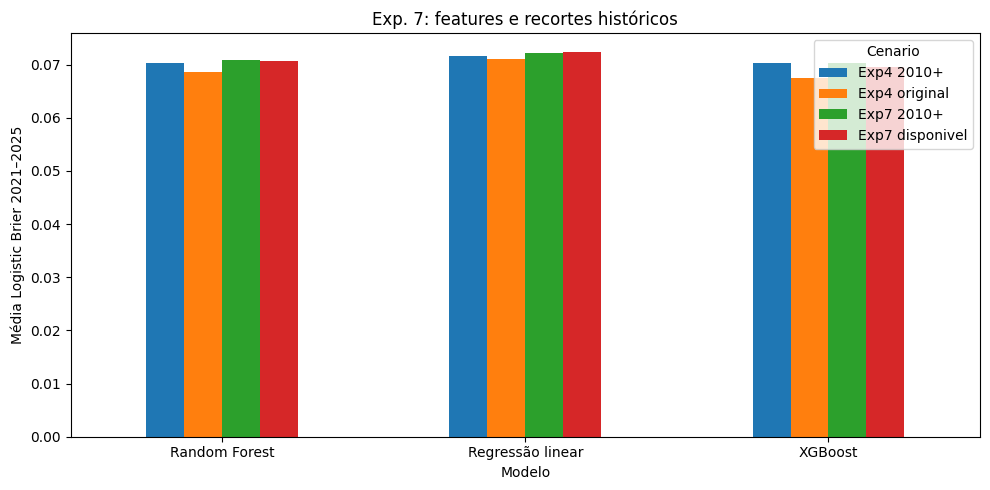

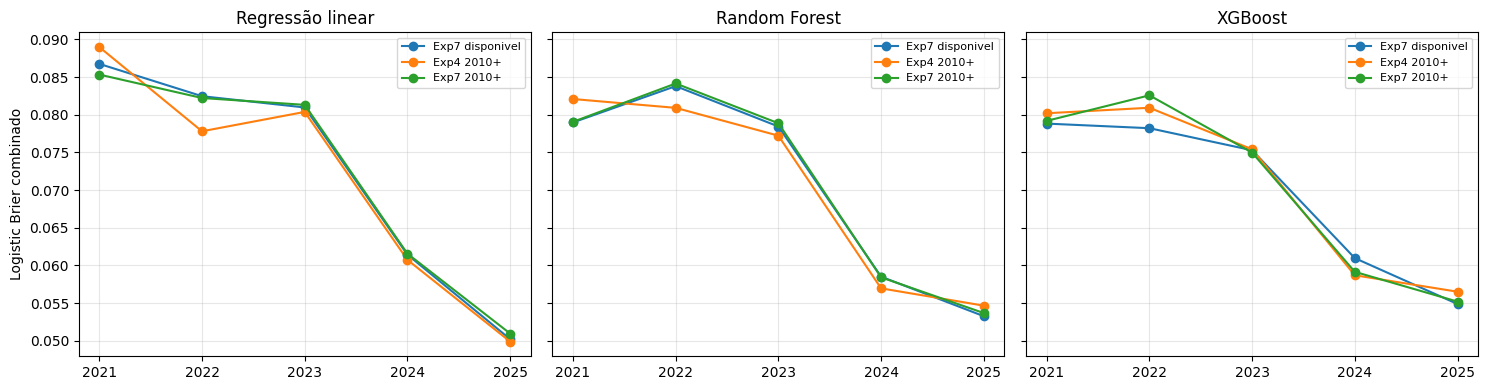

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
tabela_comparacao.plot.bar(ax=ax)
ax.set_ylabel("Média Logistic Brier 2021–2025")
ax.set_title("Exp. 7: features e recortes históricos")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

fig_anos, eixos = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, nome in zip(eixos, CRIADORES):
    for cenario, resultados in buscas_cenarios.items():
        anual = resultados[nome]["resultados"].query("Categoria == 'Combinado'")
        ax.plot(anual["Season"], anual["Score"], marker="o", label=cenario)
    ax.set_title(NOMES[nome])
    ax.set_xticks(ANOS_VALIDACAO)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
eixos[0].set_ylabel("Logistic Brier combinado")
fig_anos.tight_layout()
plt.show()


## Submissões de 2026

Geramos três CSVs do cenário principal **Exp7 disponível** (M desde 2003; W desde 2010),
treinando até 2025. Os cenários 2010+ servem à comparação. Margens brutas, sem sigmoid
ou clipping, com fallback zero para pares sem duas seeds.


In [7]:
sample_submission = dados["M"]["sample_submission"]
confrontos = preparar_confrontos(
    sample_submission, seeds["M"], seeds["W"],
    dados["M"]["times"]["TeamID"], dados["W"]["times"]["TeamID"],
    temporada=TEMPORADA_PREVISAO,
)
stats_2026 = pd.concat([
    stats.loc[stats["Season"].eq(TEMPORADA_PREVISAO)]
    for stats in estatisticas.values()
], ignore_index=True)
confrontos = adicionar_estatisticas(confrontos, stats_2026, permitir_ausentes=True)
detalhes_2026 = pd.concat([
    stats.loc[stats["Season"].eq(TEMPORADA_PREVISAO)] for stats in detalhadas.values()
], ignore_index=True)
confrontos = adicionar_estatisticas_detalhadas(confrontos, detalhes_2026, permitir_ausentes=True)
participantes = confrontos["TemDuasSeeds"]
assert (confrontos["TeamA"] < confrontos["TeamB"]).all()
assert np.isfinite(confrontos.loc[participantes, FEATURES].to_numpy()).all()
stats_index = stats_2026.set_index(["Season", "TeamID"])
for nome in ["WinRate", "AvgPointsFor", "AvgPointsAgainst", "OppWinRate"]:
    pares = confrontos.loc[participantes]
    a = stats_index[nome].reindex(pd.MultiIndex.from_frame(pares[["Season", "TeamA"]])).to_numpy()
    b = stats_index[nome].reindex(pd.MultiIndex.from_frame(pares[["Season", "TeamB"]])).to_numpy()
    np.testing.assert_allclose(pares[f"{nome}Diff"], a - b)

lookup = detalhes_2026.set_index(["Season", "TeamID"])
pares = confrontos.loc[participantes]
for nome in ESTATISTICAS_DETALHADAS:
    a = lookup[nome].reindex(pd.MultiIndex.from_frame(pares[["Season", "TeamA"]])).to_numpy()
    b = lookup[nome].reindex(pd.MultiIndex.from_frame(pares[["Season", "TeamB"]])).to_numpy()
    np.testing.assert_allclose(pares[nome + "Diff"], a - b)

modelos_finais, arquivos_submission, resumo_submissions = {}, {}, []
for nome, criar_modelo in CRIADORES.items():
    modelos_finais[nome] = {}
    for categoria, tabela in jogos.items():
        treino = tabela.loc[tabela["Season"] < TEMPORADA_PREVISAO]
        assert treino["Season"].max() == 2025
        assert treino["TeamA"].isin(dados[categoria]["times"]["TeamID"]).all()
        assert treino["TeamB"].isin(dados[categoria]["times"]["TeamID"]).all()
        modelo = criar_modelo(**buscas[nome]["parametros"])
        modelo.fit(treino[FEATURES], treino["Target"])
        modelos_finais[nome][categoria] = modelo
    assert modelos_finais[nome]["M"] is not modelos_finais[nome]["W"]
    previsoes = prever_confrontos(
        confrontos, modelos_finais[nome]["M"], modelos_finais[nome]["W"], features=FEATURES,
    )
    assert previsoes.loc[~participantes, "Pred"].eq(0).all()
    assert previsoes["ID"].equals(sample_submission["ID"])
    caminho = salvar_submission(
        previsoes, sample_submission,
        raiz / "submissions" / f"submission_exp7_features_detalhadas_{nome}_{TEMPORADA_PREVISAO}.csv",
    )
    arquivos_submission[nome] = caminho
    resumo_submissions.append({
        "Modelo": NOMES[nome], "Arquivo": caminho.name,
        "Linhas": len(previsoes), "ParesParticipantes": int(participantes.sum()),
        "MinPred": previsoes["Pred"].min(), "MaxPred": previsoes["Pred"].max(),
    })
display(pd.DataFrame(resumo_submissions))


,Modelo,Arquivo,Linhas,ParesParticipantes,MinPred,MaxPred
0,Regressão linear,submission_exp7_features_detalhadas_linear_202...,132133,4556,-52.856822,59.169020
1,Random Forest,submission_exp7_features_detalhadas_random_for...,132133,4556,-32.147833,43.577345
2,XGBoost,submission_exp7_features_detalhadas_xgboost_20...,132133,4556,-23.016035,29.337172


## Registro

Resultados e configurações ficam no notebook; somente as submissões são gravadas fora dele.


In [8]:
registro = {
    "experimento": EXPERIMENTO, "features": FEATURES, "features_exp4": FEATURES_EXP4,
    "anos_validacao": ANOS_VALIDACAO, "temporada_previsao": TEMPORADA_PREVISAO,
    "inicio_detalhado": INICIO_DETALHADO, "inicio_comum": INICIO_COMUM,
    "cenario_submission": CENARIO_PRINCIPAL, "limite_daynum_2026": LIMITE_DAYNUM_PREVISAO,
    "objetivo": "Media simples dos scores anuais combinados M/W", "seed": SEED,
    "n_trials_por_cenario": N_TRIALS, "espacos_busca": ESPACOS, "parametros_fixos": PARAMETROS_FIXOS,
    "melhores_parametros": {c: {n: r["parametros"] for n, r in resultados.items()} for c, resultados in buscas_cenarios.items()},
    "melhores_medias": {c: {n: r["media"] for n, r in resultados.items()} for c, resultados in buscas_cenarios.items()},
    "scores_anuais": scores_anuais.to_dict(orient="records"),
    "comparacao": comparacao.to_dict(orient="records"), "referencia_exp4": REFERENCIA_EXP4,
    "cobertura": cobertura.to_dict(orient="records"),
    "definicao_percentuais": "Soma dos acertos / soma das tentativas (0 a 1)",
    "definicao_medias": "Por jogo detalhado disponivel, sem ajuste por prorrogacao",
    "versoes": {p: version(p) for p in ["numpy", "pandas", "scikit-learn", "xgboost", "optuna"]},
    "arquivos_submission": {nome: str(path.relative_to(raiz)) for nome, path in arquivos_submission.items()},
}
display(registro)


{'experimento': 'exp7_features_detalhadas',
 'features': ['SeedDif',
  'WinRateDiff',
  'AvgPointsForDiff',
  'AvgPointsAgainstDiff',
  'OppWinRateDiff',
  'FGPercentageDiff',
  'ThreePointPercentageDiff',
  'FTPercentageDiff',
  'AssistsPerGameDiff',
  'OffensiveReboundsPerGameDiff',
  'DefensiveReboundsPerGameDiff',
  'TurnoversPerGameDiff',
  'StealsPerGameDiff',
  'BlocksPerGameDiff'],
 'features_exp4': ['SeedDif',
  'WinRateDiff',
  'AvgPointsForDiff',
  'AvgPointsAgainstDiff',
  'OppWinRateDiff'],
 'anos_validacao': [2021, 2022, 2023, 2024, 2025],
 'temporada_previsao': 2026,
 'inicio_detalhado': {'M': 2003, 'W': 2010},
 'inicio_comum': 2010,
 'cenario_submission': 'Exp7 disponivel',
 'limite_daynum_2026': 134,
 'objetivo': 'Media simples dos scores anuais combinados M/W',
 'seed': 42,
 'n_trials_por_cenario': {'linear': 2, 'random_forest': 30, 'xgboost': 30},
 'espacos_busca': {'linear': {'fit_intercept': {'tipo': 'categorical',
    'choices': [False, True]}},
  'random_forest':